In [6]:
import pandas as pd

file_path = r"C:\Users\HomePC\Desktop\market_pipe_thickness_loss_dataset(1).csv.xlsx"
df = pd.read_excel(file_path)

print(df.head())

   Pipe_Size_mm  Thickness_mm      Material              Grade  \
0           800            15  Carbon Steel  ASTM A333 Grade 6   
1           800            22           PVC  ASTM A106 Grade B   
2           400            12  Carbon Steel         API 5L X52   
3          1500            39  Carbon Steel         API 5L X42   
4          1500            24          HDPE         API 5L X65   

   Max_Pressure_psi  Temperature_C  Corrosion_Impact_Percent  \
0               300           84.9                     16.04   
1               150           14.1                      7.38   
2              2500            0.6                      2.12   
3              1500           52.7                      5.58   
4              1500           11.7                     12.29   

   Thickness_Loss_mm  Material_Loss_Percent  Time_Years Condition  
0                  5                  31.72           2  Moderate  
1                  7                  33.27           4  Critical  
2             

In [7]:
print(df.shape)

df.info()

df.head()

df.isnull().sum()

df["Condition"].value_counts()

(1000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pipe_Size_mm              1000 non-null   int64  
 1   Thickness_mm              1000 non-null   int64  
 2   Material                  1000 non-null   object 
 3   Grade                     1000 non-null   object 
 4   Max_Pressure_psi          1000 non-null   int64  
 5   Temperature_C             1000 non-null   float64
 6   Corrosion_Impact_Percent  1000 non-null   float64
 7   Thickness_Loss_mm         1000 non-null   int64  
 8   Material_Loss_Percent     1000 non-null   float64
 9   Time_Years                1000 non-null   int64  
 10  Condition                 1000 non-null   object 
dtypes: float64(3), int64(5), object(3)
memory usage: 86.1+ KB


Condition
Critical    487
Moderate    299
Normal      214
Name: count, dtype: int64

In [8]:
# View class distribution
print(df["Condition"].value_counts())

# View percentages
print(df["Condition"].value_counts(normalize=True) * 100)

Condition
Critical    487
Moderate    299
Normal      214
Name: count, dtype: int64
Condition
Critical    48.7
Moderate    29.9
Normal      21.4
Name: proportion, dtype: float64


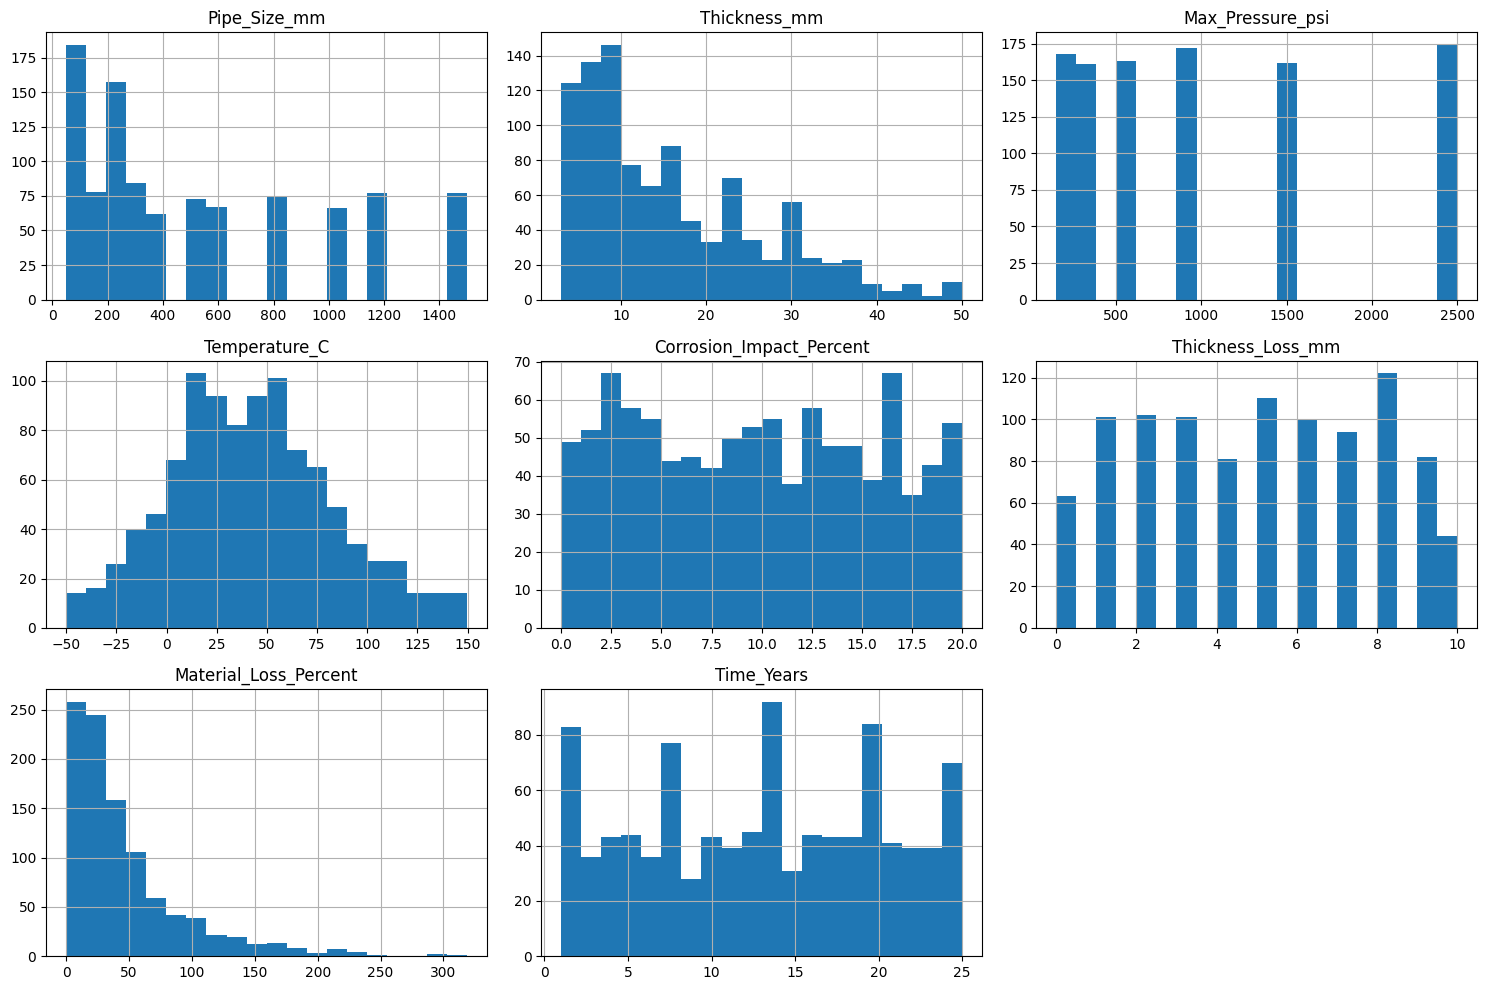

In [9]:
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Histograms
df[numeric_cols].hist(figsize=(15,10), bins=20)

plt.tight_layout()
plt.show()

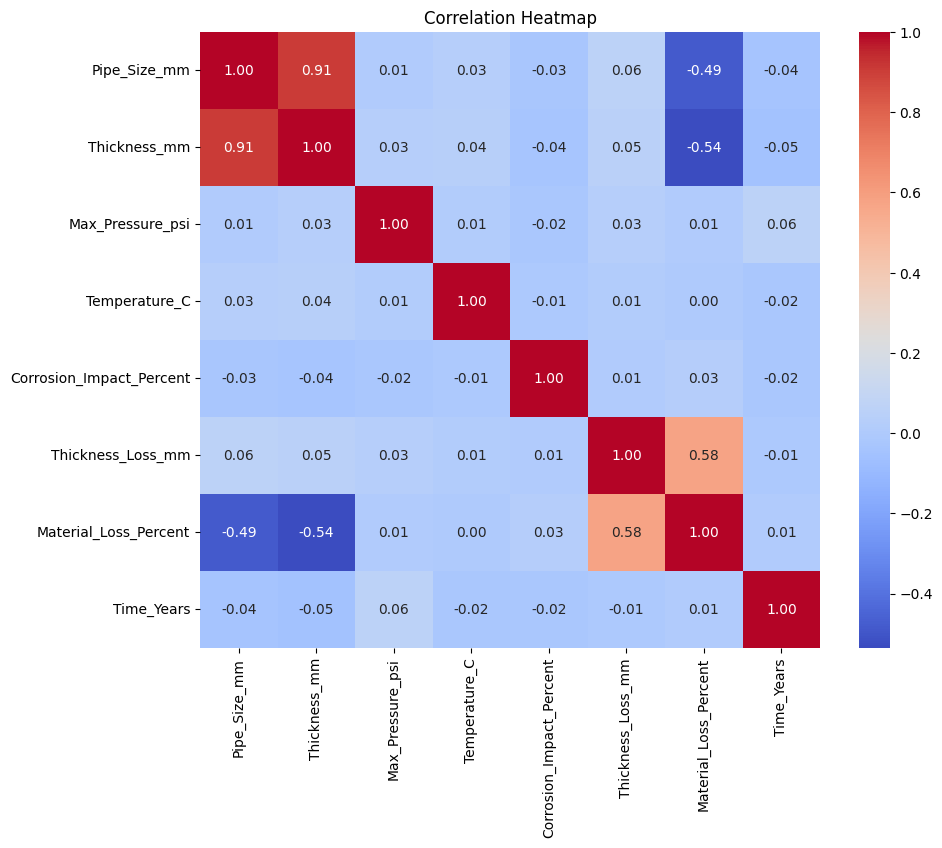

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

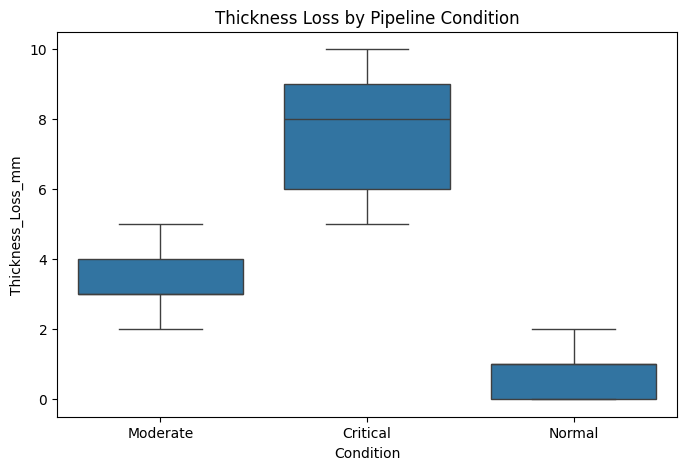

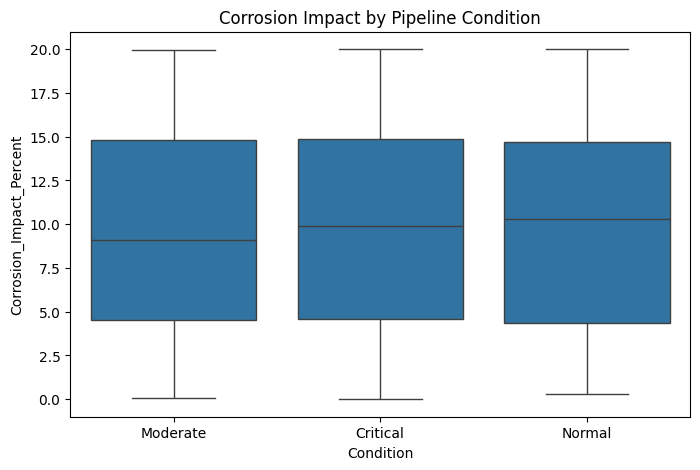

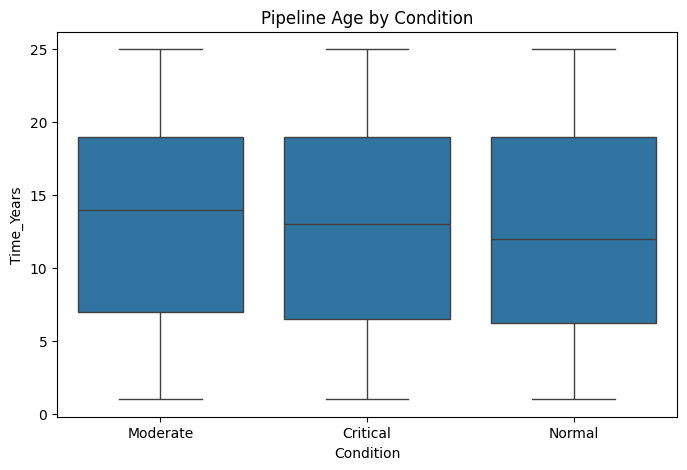

In [ ]:
# Boxplots for three numeric variables against the "Condition" column
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Condition",
    y="Thickness_Loss_mm" # Boxplot for Thickness Loss by Pipeline Condition
)

plt.title("Thickness Loss by Pipeline Condition")
plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Condition",
    y="Corrosion_Impact_Percent" # Boxplot for Corrosion Impact by Pipeline Condition
)

plt.title("Corrosion Impact by Pipeline Condition")
plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Condition",
    y="Time_Years" # Boxplot for Pipeline Age by Pipeline Condition
)

plt.title("Pipeline Age by Condition")
plt.show()

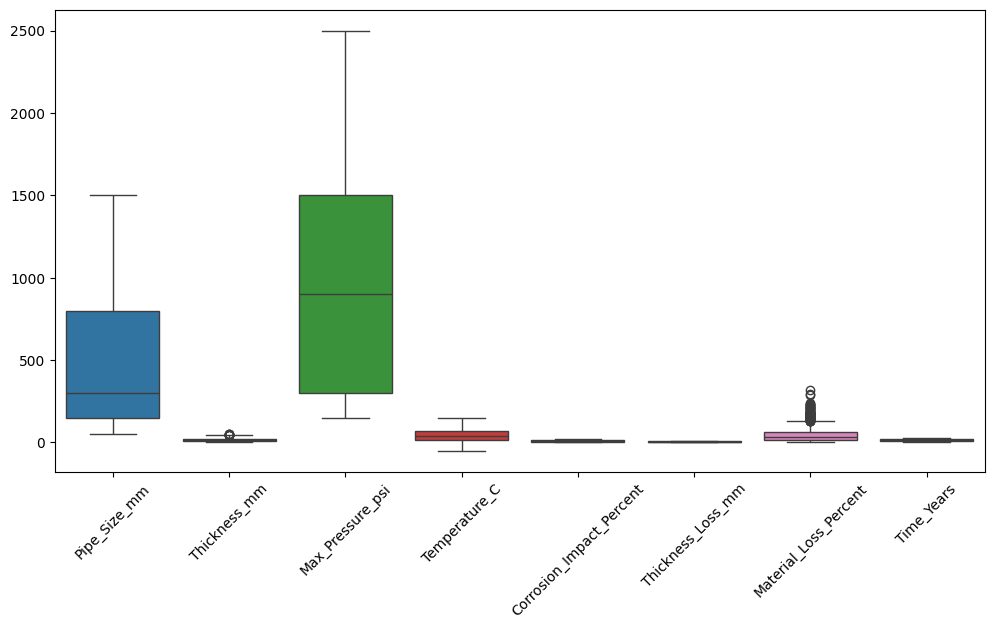

In [ ]:
# Boxplots for all numeric variables
plt.figure(figsize=(12,6))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45)

plt.show() 

In [13]:
grouped = df.groupby("Condition")[numeric_cols].mean()

print(grouped)

           Pipe_Size_mm  Thickness_mm  Max_Pressure_psi  Temperature_C  \
Condition                                                                
Critical     557.494867     16.737166       1004.414784      43.252567   
Moderate     464.882943     14.849498       1017.224080      40.078595   
Normal       521.028037     16.257009        985.046729      44.617290   

           Corrosion_Impact_Percent  Thickness_Loss_mm  Material_Loss_Percent  \
Condition                                                                       
Critical                   9.794702           7.468172              70.153018   
Moderate                   9.589097           3.531773              35.758562   
Normal                     9.854346           0.939252               8.837523   

           Time_Years  
Condition              
Critical    12.792608  
Moderate    13.478261  
Normal      12.621495  


In [14]:
df["Material_Loss_Percent"].describe()

print(df["Material_Loss_Percent"].max())

df.nlargest(10, "Material_Loss_Percent")

318.75


,Pipe_Size_mm,Thickness_mm,Material,Grade,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Condition
256,50,3,Carbon Steel,ASTM A106 Grade B,300,32.6,4.60,10,318.75,15,Critical
263,50,3,Fiberglass,ASTM A333 Grade 6,1500,34.6,5.32,10,292.92,11,Critical
225,50,3,PVC,API 5L X52,2500,88.0,14.16,10,289.43,18,Critical
724,50,4,Fiberglass,ASTM A333 Grade 6,300,63.5,4.65,9,240.11,2,Critical
35,50,4,PVC,ASTM A333 Grade 6,150,63.0,16.94,10,235.31,1,Critical
926,100,4,HDPE,ASTM A106 Grade B,2500,66.9,1.39,9,231.62,20,Critical
296,100,4,HDPE,ASTM A106 Grade B,900,131.5,17.74,10,225.86,11,Critical
235,50,4,Carbon Steel,ASTM A333 Grade 6,600,-13.4,18.10,8,224.66,5,Critical
746,50,3,PVC,ASTM A333 Grade 6,900,75.5,19.11,7,220.94,4,Critical
922,100,4,PVC,API 5L X52,1500,16.9,11.22,10,219.08,10,Critical


In [15]:
    # Records where thickness loss exceeds wall thickness
invalid_records = df[df["Thickness_Loss_mm"] > df["Thickness_mm"]]

print(f"Number of physically inconsistent records: {len(invalid_records)}")

# Percentage of the dataset
print(f"Percentage: {len(invalid_records)/len(df)*100:.2f}%")

# Preview a few examples
invalid_records.head()

Number of physically inconsistent records: 101
Percentage: 10.10%


,Pipe_Size_mm,Thickness_mm,Material,Grade,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Condition
13,150,5,HDPE,ASTM A333 Grade 6,300,43.6,16.02,6,117.92,13,Critical
15,100,6,Fiberglass,API 5L X65,1500,60.1,18.79,7,116.83,21,Critical
21,100,6,Carbon Steel,ASTM A106 Grade B,1500,45.3,12.17,8,133.63,10,Critical
34,50,5,PVC,ASTM A333 Grade 6,600,51.7,14.89,9,195.82,1,Critical
35,50,4,PVC,ASTM A333 Grade 6,150,63.0,16.94,10,235.31,1,Critical


In [19]:
import pandas as pd

# Create a working copy
df_ml = df.copy()

# Features
X = df_ml.drop("Condition", axis=1)

# Target
y = df_ml["Condition"]

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(label_encoder.classes_)

X = pd.get_dummies(
    X,
    columns=["Material", "Grade"],
    drop_first=True
)

print(X.head())

print("Number of features:", X.shape[1])

print(X.columns)


['Critical' 'Moderate' 'Normal']
   Pipe_Size_mm  Thickness_mm  Max_Pressure_psi  Temperature_C  \
0           800            15               300           84.9   
1           800            22               150           14.1   
2           400            12              2500            0.6   
3          1500            39              1500           52.7   
4          1500            24              1500           11.7   

   Corrosion_Impact_Percent  Thickness_Loss_mm  Material_Loss_Percent  \
0                     16.04                  5                  31.72   
1                      7.38                  7                  33.27   
2                      2.12                  6                  52.45   
3                      5.58                  6                  16.01   
4                     12.29                  9                  35.28   

   Time_Years  Material_Fiberglass  Material_HDPE  Material_PVC  \
0           2                False          False         False 

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

numerical_cols = [
    "Pipe_Size_mm",
    "Thickness_mm",
    "Max_Pressure_psi",
    "Temperature_C",
    "Corrosion_Impact_Percent",
    "Thickness_Loss_mm",
    "Material_Loss_Percent",
    "Time_Years"
]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)
print("Original feature matrix:", X.shape)

print("Training:", X_train.shape)

print("Testing:", X_test.shape)

print("\nScaled training sample:")

X_train_scaled.head()

Training set: (800, 16)
Testing set: (200, 16)
Original feature matrix: (1000, 16)
Training: (800, 16)
Testing: (200, 16)

Scaled training sample:


,Pipe_Size_mm,Thickness_mm,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Material_Fiberglass,Material_HDPE,Material_PVC,Material_Stainless Steel,Grade_API 5L X52,Grade_API 5L X65,Grade_ASTM A106 Grade B,Grade_ASTM A333 Grade 6
502,-0.838278,-1.049432,-1.064191,1.163869,-0.706440,-1.322499,-0.454833,1.554037,False,False,False,True,False,True,False,False
465,0.182802,-0.478313,0.616848,1.734587,1.372815,-1.322499,-0.848536,0.284428,False,True,False,False,False,False,False,True
694,1.544241,0.568740,-1.064191,2.084691,-1.282101,1.069618,-0.259489,-0.138775,False,False,True,False,False,False,True,False
401,2.224961,2.186912,-0.877409,-1.354004,-0.543192,-0.639037,-0.833245,0.848699,False,True,False,False,False,False,False,True
677,2.224961,1.901352,-0.877409,0.247843,0.881355,-0.639037,-0.807400,-1.267317,False,False,True,False,False,False,False,True
